In [ ]:
import re
import pandas as pd
import kagglehub
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
path = kagglehub.dataset_download("PromptCloudHQ/amazon-reviews-unlocked-mobile-phones")
data = pd.read_csv(f"{path}/Amazon_Unlocked_Mobile.csv")

In [3]:
data.head()
data.isna().sum()
data = data.dropna(subset=["Reviews"]).drop_duplicates(subset=["Reviews"])
data["Sentiment"] = data["Rating"].apply(lambda r: "positive" if r > 3 else ("negative" if r < 3 else "neutral"))
data["Sentiment"].value_counts()

Sentiment
positive    103773
negative     44351
neutral      14366
Name: count, dtype: int64

In [4]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [ps.stem(w) for w in words]
    return " ".join(words)

nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))
ps = PorterStemmer()

data["Reviews"] = data["Reviews"].apply(preprocess)
data[["Reviews", "Sentiment"]].head()

,Reviews,Sentiment
0,feel lucki found use phone us use hard phone l...,positive
1,nice phone nice grade pantach revu clean set e...,positive
2,pleas,positive
3,work good goe slow sometim good phone love,positive
4,great phone replac lost phone thing volum butt...,positive


In [5]:
X_train, X_test, y_train, y_test = train_test_split(data["Reviews"], data["Sentiment"], test_size=0.2, random_state=42, stratify=data["Sentiment"])
print(X_train.shape, X_test.shape)

(129992,) (32498,)


In [6]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)
print(X_train_vec.shape, X_test_vec.shape)

(129992, 5000) (32498, 5000)


In [7]:
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [8]:
predictions = nb.predict(X_test_vec)
print("Accuracy:", round(accuracy_score(y_test, predictions), 4))
print(classification_report(y_test, predictions))

Accuracy: 0.8072
              precision    recall  f1-score   support

    negative       0.80      0.70      0.75      8870
     neutral       0.23      0.01      0.02      2873
    positive       0.81      0.96      0.88     20755

    accuracy                           0.81     32498
   macro avg       0.61      0.56      0.55     32498
weighted avg       0.76      0.81      0.77     32498



[[ 6215    41  2614]
 [  874    33  1966]
 [  699    71 19985]]


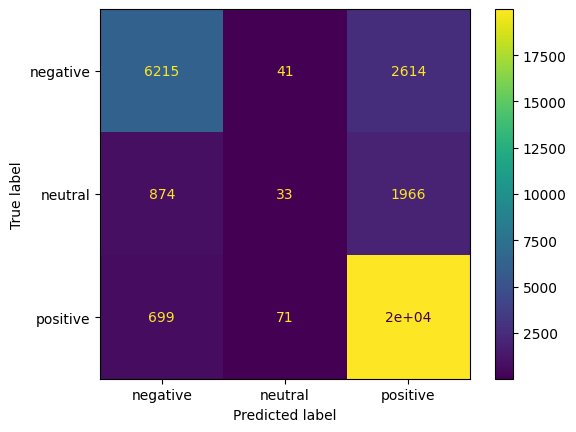

In [9]:
cm = confusion_matrix(y_test, predictions, labels=nb.classes_)
print(cm)
ConfusionMatrixDisplay(cm, display_labels=nb.classes_).plot();